# GPU-accelerated fragment searching with nvMolKit

*Draft guest post from Kevin Boyd at NVIDIA.*

This post uses the 85 SMARTS patterns behind RDKit's fragment descriptors as a
realistic query set and searches them against one million Enamine REAL molecules.
For each target/query pair we record whether the fragment is present, producing
a one-million by 85 boolean fragment-feature matrix.

The RDKit comparison uses `SubstructLibrary` with 16 native CPU threads. The
nvMolKit comparison searches the same molecules and queries on an NVIDIA GPU.

## Imports and configuration

The results below use official binary installations of RDKit and nvMolKit 0.6.
The benchmark machine has an NVIDIA GeForce RTX 5080 and an AMD Ryzen 9 9950X.
SMILES parsing and construction of the RDKit substructure library are preparation
steps and are not included in the search timings.

In [1]:
from pathlib import Path
from time import perf_counter
import csv
import importlib.metadata
import os
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from rdkit import Chem, RDConfig, rdBase
from rdkit.Chem import rdSubstructLibrary

from nvmolkit.substructure import SubstructSearchConfig, hasSubstructMatch

print("Python:", platform.python_version())
print("RDKit:", rdBase.rdkitVersion)
print("nvMolKit:", importlib.metadata.version("nvmolkit"))
print("PyTorch:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0))
print("nvMolKit loaded from:", importlib.util.find_spec("nvmolkit").origin)

Python: 3.14.4
RDKit: 2026.03.5
nvMolKit: 0.6.0
PyTorch: 2.13.0+cu130
GPU: NVIDIA GeForce RTX 5080
nvMolKit loaded from: /home/kevin/programs/miniforge3/envs/nvmolkit_iface_py3.14/lib/python3.14/site-packages/nvmolkit/__init__.py


In [2]:
n_mols = 1_000_000
n_cpu_threads = 16

smi_file = Path("../data/enamine_real_10M.csxmiles")
if not smi_file.exists():
    smi_file = Path("/home/kevin/data/enamine_real_10M.csxmiles")
assert smi_file.exists(), f"Enamine REAL file not found: {smi_file}"

fragment_file = Path(RDConfig.RDDataDir) / "FragmentDescriptors.csv"

## Loading the fragment queries

RDKit's `FragmentDescriptors.csv` contains the names, descriptions, and SMARTS
definitions used by `rdkit.Chem.Fragments`. We use every pattern as an independent
boolean substructure query. This asks whether each descriptor fragment is present;
it does not count multiple embeddings of the same SMARTS.

In [3]:
fragment_names = []
fragment_descriptions = []
fragment_queries = []
with fragment_file.open() as inf:
    for row in csv.reader(inf, delimiter="\t"):
        if len(row) < 3 or not row[0] or row[0].startswith("#"):
            continue
        fragment_names.append(row[0])
        fragment_descriptions.append(row[1].strip('"'))
        fragment_queries.append(Chem.MolFromSmarts(row[2]))

assert all(fragment_queries)
print(f"Loaded {len(fragment_queries)} RDKit fragment SMARTS")
pd.DataFrame({"name": fragment_names, "description": fragment_descriptions}).head(10)

Loaded 85 RDKit fragment SMARTS


,name,description
0,fr_C=O,Number of carbonyl O
1,fr_C=O_noCOO,"Number of carbonyl O, excluding COOH"
2,fr_Al_OH,Number of aliphatic hydroxyl groups
3,fr_Ar_OH,Number of aromatic hydroxyl groups
4,fr_methoxy,Number of methoxy groups -OCH3
5,fr_oxime,Number of oxime groups
6,fr_ester,Number of esters
7,fr_Al_COO,Number of aliphatic carboxylic acids
8,fr_Ar_COO,Number of Aromatic carboxylic acide
9,fr_COO,Number of carboxylic acids


## Loading one million Enamine REAL molecules

nvMolKit 0.6 does not currently model isotope-sensitive substructure matching.
The Enamine sample contains a small number of explicitly isotope-labelled
molecules, mostly deuterated compounds, so those are excluded to keep the two
result matrices semantically identical. Parsing is outside the benchmark.

In [4]:
mols = []
n_parse_failures = 0
n_isotope_filtered = 0

with smi_file.open() as inf:
    next(inf)
    for line in inf:
        mol = Chem.MolFromSmiles(line.split("\t", 1)[0])
        if mol is None:
            n_parse_failures += 1
            continue
        if any(atom.GetIsotope() for atom in mol.GetAtoms()):
            n_isotope_filtered += 1
            continue
        mols.append(mol)
        if len(mols) == n_mols:
            break

print(f"Loaded {len(mols):,} molecules")
print(f"Parse failures skipped: {n_parse_failures:,}")
print(f"Isotope-labelled molecules skipped: {n_isotope_filtered:,}")

Loaded 1,000,000 molecules
Parse failures skipped: 0
Isotope-labelled molecules skipped: 2,859


## Correctness check

Before timing the full search, compare the complete 10,000 by 85 boolean matrix.
The RDKit reference here directly calls `HasSubstructMatch`; nvMolKit processes
the same targets and queries as one batch.

In [5]:
config = SubstructSearchConfig(preprocessingThreads=n_cpu_threads, gpuIds=[0])

validation_mols = mols[:10_000]
rdkit_validation = np.array([
    [mol.HasSubstructMatch(query) for query in fragment_queries]
    for mol in validation_mols
])
nvmolkit_validation = hasSubstructMatch(validation_mols, fragment_queries, config)

assert np.array_equal(rdkit_validation, nvmolkit_validation)
print(f"Exact agreement for {rdkit_validation.size:,} target/query pairs")

Exact agreement for 850,000 target/query pairs


## RDKit search

`CachedMolHolder` stores binary molecule representations, reducing the memory
used by the search library. Library construction is not timed. Each of the 85
queries searches the complete library using 16 RDKit threads, and `maxResults=-1`
ensures that all matching molecule indices are returned.

In [6]:
holder = rdSubstructLibrary.CachedMolHolder()
rdkit_library = rdSubstructLibrary.SubstructLibrary(holder)
for mol in mols:
    rdkit_library.AddMol(mol)

t0 = perf_counter()
rdkit_match_counts = np.array([
    len(rdkit_library.GetMatches(query, numThreads=n_cpu_threads, maxResults=-1))
    for query in fragment_queries
])
rdkit_search_time = perf_counter() - t0

print(f"RDKit search: {rdkit_search_time:.2f} s")
print(f"Positive target/query pairs: {rdkit_match_counts.sum():,}")

RDKit search: 44.99 s
Positive target/query pairs: 8,835,830


## nvMolKit search

An untimed 100-molecule call initializes the CUDA context. The measured call
includes nvMolKit preprocessing, GPU execution, and returning the boolean NumPy
matrix to the host.

In [7]:
hasSubstructMatch(mols[:100], fragment_queries, config)

t0 = perf_counter()
nvmolkit_matches = hasSubstructMatch(mols, fragment_queries, config)
nvmolkit_search_time = perf_counter() - t0

nvmolkit_match_counts = nvmolkit_matches.sum(axis=0)
assert np.array_equal(rdkit_match_counts, nvmolkit_match_counts)

print(f"nvMolKit search: {nvmolkit_search_time:.2f} s")
print(f"Positive target/query pairs: {int(nvmolkit_match_counts.sum()):,}")
print(f"Speedup: {rdkit_search_time / nvmolkit_search_time:.1f}x")

nvMolKit search: 1.43 s
Positive target/query pairs: 8,835,830
Speedup: 31.5x


## Results

The left panel compares total search time. The right panel uses the actual
boolean result matrix to show the most prevalent RDKit fragment patterns in
this one-million-molecule sample.

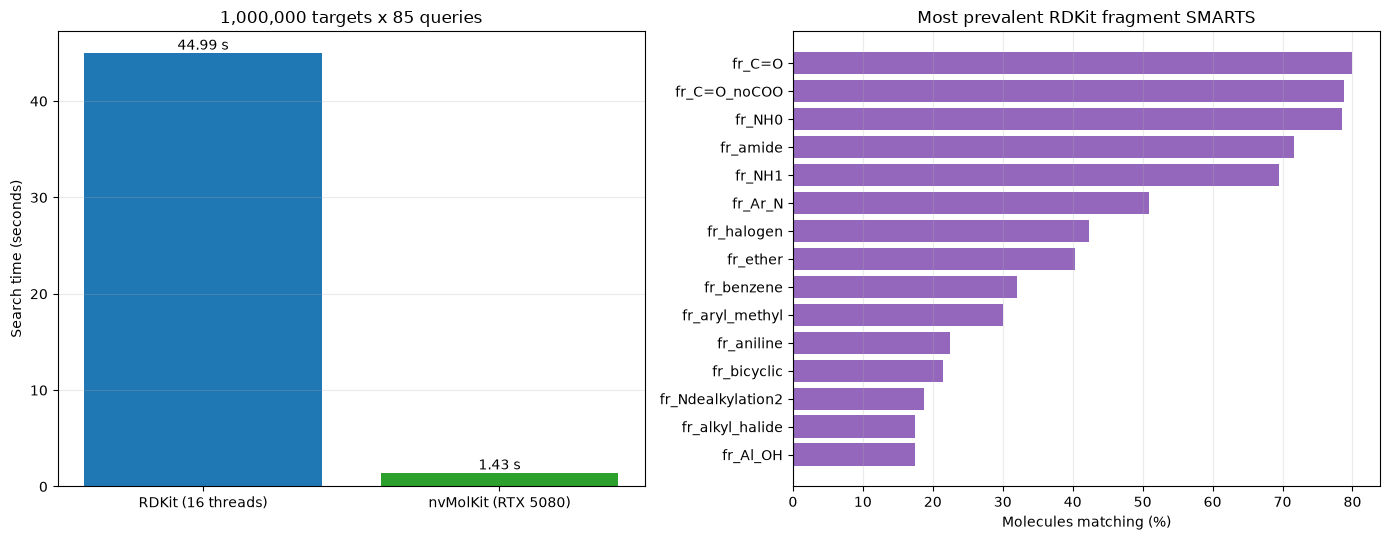

,name,description,matching molecules,prevalence
0,fr_C=O,Number of carbonyl O,799401,0.799401
1,fr_C=O_noCOO,"Number of carbonyl O, excluding COOH",787906,0.787906
2,fr_NH0,Number of Tertiary amines,784688,0.784688
3,fr_amide,Number of amides,716306,0.716306
4,fr_NH1,Number of Secondary amines,694837,0.694837
5,fr_Ar_N,Number of aromatic nitrogens,508685,0.508685
6,fr_halogen,Number of halogens,423879,0.423879
7,fr_ether,Number of ether oxygens (including phenoxy),403551,0.403551
8,fr_benzene,Number of benzene rings,320777,0.320777
9,fr_aryl_methyl,Number of aryl methyl sites for hydroxylation,300315,0.300315


In [8]:
fragment_results = pd.DataFrame({
    "name": fragment_names,
    "description": fragment_descriptions,
    "matching molecules": nvmolkit_match_counts.astype(int),
})
fragment_results["prevalence"] = fragment_results["matching molecules"] / n_mols
fragment_results = fragment_results.sort_values("matching molecules", ascending=False).reset_index(drop=True)

timings = pd.DataFrame({
    "backend": ["RDKit (16 threads)", "nvMolKit (RTX 5080)"],
    "seconds": [rdkit_search_time, nvmolkit_search_time],
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
bars = ax1.bar(timings["backend"], timings["seconds"], color=["#1f77b4", "#2ca02c"])
ax1.set_ylabel("Search time (seconds)")
ax1.set_title(f"{n_mols:,} targets x {len(fragment_queries)} queries")
ax1.grid(axis="y", alpha=0.25)
for bar, value in zip(bars, timings["seconds"]):
    ax1.text(bar.get_x() + bar.get_width()/2, value, f"{value:.2f} s", ha="center", va="bottom")

top = fragment_results.head(15).sort_values("prevalence")
ax2.barh(top["name"], 100 * top["prevalence"], color="#9467bd")
ax2.set_xlabel("Molecules matching (%)")
ax2.set_title("Most prevalent RDKit fragment SMARTS")
ax2.grid(axis="x", alpha=0.25)

fig.tight_layout()
plt.show()

fragment_results.head(15)

## Conclusions

This is an 85-million-pair substructure workflow, not a single-query
microbenchmark. RDKit's `SubstructLibrary` provides a compact and genuinely
multithreaded CPU baseline, while nvMolKit accepts the natural batched form:
a list of targets and a list of queries.

The complete result matrix, per-fragment totals, timings, and plotted figure data
remain embedded in this pre-run notebook. See the
[nvMolKit documentation](https://nvidia-bionemo.github.io/nvMolKit/) and
[source repository](https://github.com/NVIDIA-BioNeMo/nvMolKit) for more.